## Import packages

In [1]:
import os
import numpy as np
import h5py
from tqdm import tqdm
import pandas as pd
from pathlib import Path, PurePath
from Bio import SeqIO

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import sinabro_v2 as snbr

/home/ceel/miniconda3/envs/seta_demo/lib/python3.9/site-packages/Bio/codonalign/__init__.py:23: BiopythonExperimentalWarning: Bio.codonalign is an experimental module which may undergo significant changes prior to its future official release.
  warnings.warn(


In [2]:
data_path = '/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Final_scripts/Simple_robustness_analysis_of_cds_files'
genes_fasta_file = Path(PurePath(data_path, "gencode.v40.pc_transcripts.nopary.cdsplus.fa"))

seq_records = list(SeqIO.parse(genes_fasta_file, "fasta"))

In [3]:
seq_record = seq_records[58042]

transcript_name = seq_record.id.split("|")[4]
seq = seq_record.seq

In [4]:
rhocom = snbr.RobustnessComputer(transcript_name, seq)
lrho = rhocom.compute_l_robustness(n_sim=100, 
                                   method="signature", 
                                   eval_method="blosum", 
                                   mutational_signature='SBS2', 
                                   threshold = 20,
                                   multiprocessing=True)

In [8]:
rhocom.compute_n_robustness(n_sim=1000, 
                            method="signature", 
                            mutational_signature='SBS2',
                            n = 3,
                            phi_eval = 'blosum',
                            by_score = True,
                            multiprocessing=True)

0.04880191303499097

In [7]:
rhocom.trajs[1].get_records()

[MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='.', hgvs_aa='.', mut_type='.', note='.'),
 MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='c.1342C>T', hgvs_aa='p.H448Y', mut_type='T[C>T]A', note='score: 9.0'),
 MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='c.3655G>A', hgvs_aa='p.E1219K', mut_type='T[C>T]A', note='score: 16.0'),
 MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='c.3951G>A', hgvs_aa='.', mut_type='T[C>T]A', note='score: 16.0'),
 MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='c.1695G>A', hgvs_aa='.', mut_type='T[C>T]T', note='score: 16.0'),
 MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='c.2843G>A', hgvs_aa='p.G948E', mut_type='T[C>T]C', n

In [5]:
snbr.metrics.compute_distance(rhocom.trajs[3].get_records())

1

In [7]:
snbr.metrics.compute_distance(rhocom.trajs[3].get_records(), method="blosum", threshold_hit=False)

15.0

In [5]:
lrho

2.65

In [11]:
snbr.evaluate.compute_alignment(snbr.metrics.dna_to_aa(str(rhocom.trajs[i].get_records()[0].sequence[1:-1])), snbr.metrics.dna_to_aa(str(rhocom.trajs[i].get_records()[0].sequence[1:-1]))).score

15759.0

In [9]:
l = 0
for i in range(1000):
    s = snbr.evaluate.compute_alignment(
        str(rhocom.trajs[i].get_records()[0].sequence[1:-1]),
        str(rhocom.trajs[i].get_records()[1].sequence[1:-1])).score
    l += 15759-s
    # print(15759-s)

In [10]:
l

6947.0

In [11]:
1/(l/1000)

0.14394702749388225

In [12]:
rhocom.trajs[4].get_records()

[MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='.', hgvs_aa='.', mut_type='.', note='.'),
 MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='c.2751C>T', hgvs_aa='.', mut_type='T[C>T]A', note='.')]

In [ ]:
14909

In [14]:
import csv

cancer_genes_file = '/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/Cosmic_CancerGeneCensus_v99_GRCh38.tsv'
cancer_genes = []
with open(cancer_genes_file, newline="") as tsvfile:
    reader = csv.reader(tsvfile, delimiter="\t")
    for row in reader:
        if not row:  # skip empty lines
            continue
        cancer_genes.append(row[0])

cancer_genes_records = []
# only keep transcript_name == gene+'-201' or gene+'-203'
for seq_record in seq_records:
    transcript_name = seq_record.id.split("|")[4]
    
    # English comment: check if transcript_name matches gene+'-201' or gene+'-203'
    if any(transcript_name == f"{gene}-201" or transcript_name == f"{gene}-203"
           for gene in cancer_genes):
        cancer_genes_records.append(seq_record)

print(f"Found {len(cancer_genes_records)} matching records.")

Found 985 matching records.


In [ ]:
#MAX_RECORDS = 5

# Path to output HDF5 file
h5_path = "robustness_sbs1_blosum_20.h5"

with h5py.File(h5_path, "w") as h5f:
    # create expandable dataset for transcript names (variable-length UTF-8 strings)
    dt = h5py.string_dtype(encoding="utf-8")
    transcripts_ds = h5f.create_dataset(
        "transcript", shape=(0,), maxshape=(None,), dtype=dt
    )
    # create expandable dataset for SBS2 robustness values (float64)
    sbs2_ds = h5f.create_dataset(
        "SBS1", shape=(0,), maxshape=(None,), dtype="f8"
    )

    # iterate with tqdm to show progress
    for idx, seq_record in enumerate(tqdm(cancer_genes_records, desc="Processing transcripts")):
        # if idx >= MAX_RECORDS:  # stop after MAX_RECORDS iterations
        #     break
        transcript_name = seq_record.id.split("|")[4]
        seq = seq_record.seq

        # initialize and compute robustness
        rhocom = snbr.RobustnessComputer(transcript_name, seq)
        lrho = rhocom.compute_l_robustness(
            n_sim=1000,
            method="signature",
            eval_method="blosum",
            mutational_signature="SBS1",
            threshold=20,
            multiprocessing=True
        )

        # resize datasets to accommodate one more record
        transcripts_ds.resize((idx + 1,))
        sbs2_ds.resize((idx + 1,))

        # write the new values at position idx
        transcripts_ds[idx] = transcript_name
        sbs2_ds[idx] = lrho


Processing transcripts:  13%|████▊                                | 127/985 [1:58:39<7:06:57, 29.86s/it]

In [18]:
h5_path = "robustness_sbs2_blosum_20.h5"

# 1) HDF5 파일 열기
with h5py.File(h5_path, "r") as h5f:
    # 2) 저장된 데이터셋 키와 크기 확인
    print("Datasets:", list(h5f.keys()))
    print("Transcript count:", h5f["transcript"].shape)
    print("SBS2 count:", h5f["SBS2"].shape)
    
    # 3) 처음 10개 항목만 읽어서 출력
    transcripts = h5f["transcript"][:3]
    sbs2_vals    = h5f["SBS2"][:3]
    for name, val in zip(transcripts, sbs2_vals):
        print(name, val)

    # 4) pandas DataFrame으로 불러와서 확인 (선택)
    df = pd.DataFrame({
        "transcript": h5f["transcript"][:],
        "SBS2":       h5f["SBS2"][:]
    })

print("\nDataFrame head():")
print(df)

Datasets: ['SBS2', 'transcript']
Transcript count: (985,)
SBS2 count: (985,)
b'SKI-201' 1.316
b'TNFRSF14-201' 1.262
b'PRDM16-203' 1.303

DataFrame head():
          transcript   SBS2
0         b'SKI-201'  1.316
1    b'TNFRSF14-201'  1.262
2      b'PRDM16-203'  1.303
3      b'PRDM16-201'  1.292
4       b'RPL22-201'  1.487
..               ...    ...
980      b'FLNA-201'  1.275
981      b'FLNA-203'  1.257
982     b'RPL10-201'  1.303
983     b'RPL10-203'  1.259
984     b'MTCP1-201'  1.158

[985 rows x 2 columns]


In [7]:
MAX_RECORDS = 5

transcripts = []
lrhos = []

for idx, seq_record in enumerate(tqdm(cancer_genes_records, desc="Processing transcripts")):
    if idx >= MAX_RECORDS:  # stop after MAX_RECORDS iterations
        break

    transcript_name = seq_record.id.split("|")[4]  # extract the transcript name from record id
    seq = seq_record.seq

    # initialize RobustnessComputer
    rhocom = snbr.RobustnessComputer(transcript_name, seq)

    # compute robustness with given parameters
    lrho = rhocom.compute_l_robustness(
        n_sim=1000,
        method="signature",
        eval_method="blosum",
        mutational_signature='SBS2',
        threshold=20,
        multiprocessing=True
    )

    transcripts.append(transcript_name)
    lrhos.append(lrho)

# build DataFrame and save to CSV
df = pd.DataFrame({
    "transcript": transcripts,
    "SBS2": lrhos
})
df.to_csv("robustness_sbs2_blosum_20.csv", index=False)

print(f"Processed {len(transcripts)} records (MAX_RECORDS={MAX_RECORDS}).")

Processing transcripts:   0%|                                                       | 5/4918 [02:25<39:46:11, 29.14s/it]

Processed 5 records (MAX_RECORDS=5).


In [6]:
df = pd.DataFrame({
    "transcript": transcripts,
    "SBS2": lrhos
})

# Save the DataFrame to a CSV file in the current folder
df.to_csv("robustness_sbs2_blosum_20.csv", index=False)

In [5]:
for i, seq_record in enumerate(seq_records):
    transcript_name = seq_record.id.split("|")[4]
    if transcript_name == "BRCA1-203":
        print(i)
    

58042


In [19]:
seq_record = seq_records[58042]

transcript_name = seq_record.id.split("|")[4]
seq = seq_record.seq

rhocom = snbr.RobustnessComputer(transcript_name, seq)
lrho = rhocom.compute_l_robustness(n_sim=100, 
                                   method="signature", 
                                   eval_method="blosum", 
                                   mutational_signature='SBS2', 
                                   threshold = 20,
                                   multiprocessing=True)

In [21]:
seq[-4:]

Seq('TGAC')

In [26]:
rhocom.trajs[0].get_records()

[MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='.', hgvs_aa='.', mut_type='.', note='.'),
 MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='c.5044G>A', hgvs_aa='p.E1682K', mut_type='T[C>T]A', note='score: 9.0'),
 MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='c.3640G>A', hgvs_aa='p.E1214K', mut_type='T[C>T]T', note='score: 18.0'),
 MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='c.4307C>T', hgvs_aa='p.S1436F', mut_type='T[C>T]T', note='score: 33.0')]

In [29]:
import igraph as ig
import umap
from sklearn.manifold import TSNE

In [46]:
g = ig.Graph(directed=True)

for traj in rhocom.trajs: 
    records = traj.get_records()
    
    for rec in records:
        seq_str = str(rec.sequence)  # convert Seq to plain string
        if rec.note.startswith("score:"):
            # extract numeric part after "score:"
            try:
                val = -float(note.split("score:")[1])
            except ValueError:
                val = 0.0
        else:
            val = 0.0
        
        g.add_vertex(
            name=seq_str,
            hgvs_mrna=rec.hgvs_mrna,
            hgvs_aa=rec.hgvs_aa,
            mut_type=rec.mut_type,
            score=val
        )
    
    for i in range(len(records) - 1):
        src_name = str(records[i].sequence)
        tgt_name = str(records[i+1].sequence)
        # find index with name
        src_idx = g.vs.find(name=src_name).index
        tgt_idx = g.vs.find(name=tgt_name).index
        g.add_edge(src_idx, tgt_idx)
    

In [51]:
# 1) Parse score values from g.vs["note"]; "."이면 0으로
scores = np.array(g.vs["score"])

# 2) Compute all-pairs shortest-path distances (edge weight = 1)
dist_matrix = np.array(g.shortest_paths_dijkstra())

#    inf는 연결 안 된 노드; 최댓값 * 1.5로 대체
finite = dist_matrix[np.isfinite(dist_matrix)]
maxd = finite.max() if finite.size else 1.0
dist_matrix[~np.isfinite(dist_matrix)] = maxd * 1.5

# 3) t-SNE embedding with precomputed distances
tsne = TSNE(
    n_components=2,       # 2D embedding
    metric="precomputed", # 이미 계산된 거리 행렬 사용
    perplexity=5,         # 국소성 조절 (노드 개수에 맞춰 조정)
    random_state=42
)
coords = tsne.fit_transform(dist_matrix)  # shape = (n_nodes, 2)

# 3) Grid 생성: x, y 범위를 50x50 격자로 분할
x_min, x_max = coords[:,0].min(), coords[:,0].max()
y_min, y_max = coords[:,1].min(), coords[:,1].max()
grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, 50),
    np.linspace(y_min, y_max, 50)
)

/tmp/ipykernel_513/2916511376.py:5: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  dist_matrix = np.array(g.shortest_paths_dijkstra())
/home/ceel/miniconda3/envs/seta_demo/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:691: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  warnings.warn(


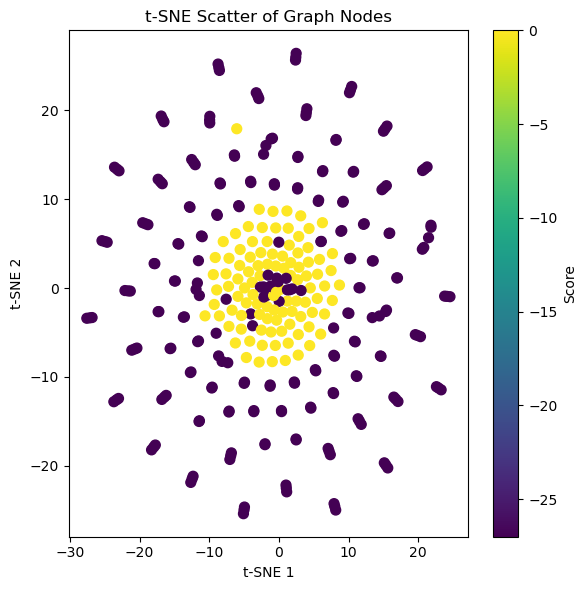

In [55]:
# 1) t-SNE scatter plot
plt.figure(figsize=(6,6))
# 점 색을 score 값에 따라 표현하고 싶다면 cmap 사용
sc = plt.scatter(
    coords[:,0], coords[:,1],
    c=scores,            # score 로 색상 매핑
    cmap='viridis',      # colormap (원하시는 것으로 변경 가능)
    s=50                 # marker size
)
plt.colorbar(sc, label='Score')  # 컬러바 추가

# 3) 축 및 제목 설정
plt.title("t-SNE Scatter of Graph Nodes")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

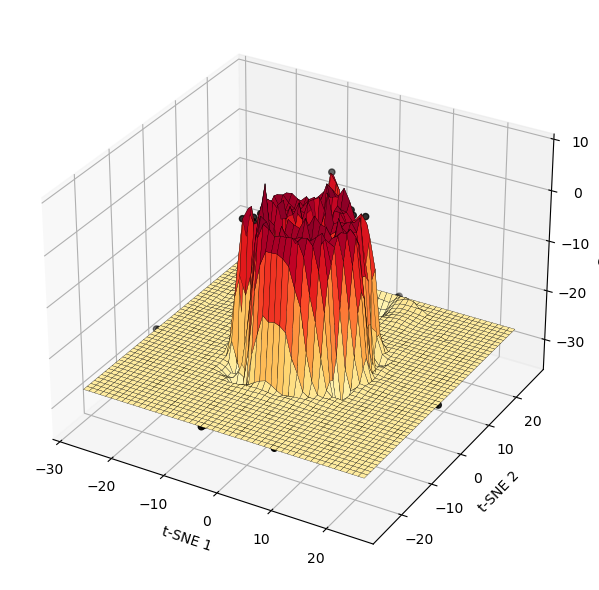

In [50]:
# 4) 불규칙한 (x,y)->score 데이터를 그리드로 보간
grid_z = griddata(
    points=(coords[:,0], coords[:,1]),  # original data points
    values=scores,                      # original z values
    xi=(grid_x, grid_y),                # target grid
    method='cubic',                     # 'linear', 'nearest' 도 가능
    fill_value=np.min(scores)                      # 보간 불가 구역은 0으로
)

# 5) 3D surface 그리기
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Triangulation 대신 plot_surface 사용
ax.plot_surface(
    grid_x, grid_y, grid_z,
    linewidth=0.2,
    antialiased=True, cmap='YlOrRd', edgecolor='black'
)

# 원본 노드 위치에 점 찍기
ax.scatter(coords[:,0], coords[:,1], scores, color='black', s=20)

# 축 레이블
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("Score")

plt.tight_layout()
plt.show()

In [42]:
# for e in g.es:
#     src_idx, tgt_idx = e.tuple
#     print(f"{src_idx} -> {tgt_idx}")

In [24]:
rhocom.trajs[1].get_records()[0].sequence[-4:]

Seq('TGAC')

In [2]:




transcripts = []
lrhos = []
for seq_record in tqdm(seq_records, desc="Processing sequences"):
    transcript_name = seq_record.id.split("|")[4]
    seq = seq_record.seq
    
    rhocom = snbr.RobustnessComputer(transcript_name, seq)

    
    lrho = rhocom.compute_l_robustness(n_sim=1000, 
                                       method="signature", 
                                       eval_method="blosum", 
                                       mutational_signature='SBS2', 
                                       threshold = 20,
                                       multiprocessing=True)

    transcripts.append(transcript_name)
    lrhos.append(lrho)

In [3]:
gene_idx = 0

transcript_name = seq_records[gene_idx].id.split("|")[4]
seq = seq_records[gene_idx].seq

rhocom = snbr.RobustnessComputer(transcript_name, seq)

In [5]:
transcripts = []
lrhos = []
for seq_record in tqdm(seq_records, desc="Processing sequences"):
    transcript_name = seq_record.id.split("|")[4]
    seq = seq_record.seq
    
    rhocom = snbr.RobustnessComputer(transcript_name, seq)

    
    lrho = rhocom.compute_l_robustness(n_sim=1000, 
                                       method="signature", 
                                       eval_method="blosum", 
                                       mutational_signature='SBS2', 
                                       threshold = 20,
                                       multiprocessing=True)

    transcripts.append(transcript_name)
    lrhos.append(lrho)
    

Processing sequences:   1%|▎                                                  | 391/73214 [1:48:16<336:05:40, 16.61s/it]


KeyboardInterrupt: 

In [4]:
transcripts = []
lrhos = []
for seq_record in tqdm(seq_records, desc="Processing sequences"):
    transcript_name = seq_record.id.split("|")[4]
    seq = seq_record.seq
    
    rhocom = snbr.RobustnessComputer(transcript_name, seq)

    lrho_thr = []
    for threshold in [10, 15, 20, 25, 30]:
        lrho = rhocom.compute_l_robustness(n_sim=1000, 
                                           method="signature", 
                                           eval_method="blosum", 
                                           mutational_signature='SBS2', 
                                           threshold = threshold,
                                           multiprocessing=True)

        lrho_thr.append(lrho)

    transcripts.append(transcript_name)
    lrhos.append(lrho_thr)
    



Processing sequences:   0%|                                                     | 6/73214 [10:51<2231:12:48, 109.72s/it]Process ForkPoolWorker-484:
Process ForkPoolWorker-483:
Process ForkPoolWorker-487:
Process ForkPoolWorker-480:
Process ForkPoolWorker-477:
Process ForkPoolWorker-481:
Process ForkPoolWorker-478:
Process ForkPoolWorker-486:
Process ForkPoolWorker-488:
Process ForkPoolWorker-485:
Process ForkPoolWorker-490:
Process ForkPoolWorker-479:
Process ForkPoolWorker-482:
Process ForkPoolWorker-489:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last)

In [13]:
rhocom.compute_l_robustness(n_sim=1000, 
                            method="signature", 
                            eval_method="nonsynonymous", 
                            mutational_signature='SBS2', 
                            multiprocessing=True)

0.89

In [4]:
rhocom.compute_l_robustness(n_sim=1000, 
                            method="signature", 
                            eval_method="blosum", 
                            mutational_signature='SBS2', 
                            threshold = 20,
                            multiprocessing=True)

1.184

In [8]:
transcript_name

'OR4F5-201'

In [7]:
rhocom.trajs[3].get_records()

[MutationRecord(sequence=Seq('TATGAAGAAGGTAACTGCAGAGGCTATTTCCTGGAATGAATCAACGAGTGAAAC...AGA'), hgvs_mrna='.', hgvs_aa='.', mut_type='.', note='.'),
 MutationRecord(sequence=Seq('TATGAAGAAGGTAACTGCAGAGGCTATTTCCTGGAATGAATCAACGAGTGAAAC...AGA'), hgvs_mrna='c.733G>A', hgvs_aa='p.D245N', mut_type='T[C>T]T', note='score: 9.0'),
 MutationRecord(sequence=Seq('TATGAAGAAGGTAACTGCAGAGGCTATTTCCTGGAATGAATCAACGAGTGAAAC...AGA'), hgvs_mrna='c.242C>T', hgvs_aa='p.S81L', mut_type='T[C>T]A', note='score: 24.0')]

In [4]:
rhocom.compute_n_robustness(n_sim=1000, 
                            method="signature", 
                            mutational_signature='SBS2',
                            n = 1,
                            phi_eval = 'blosum',
                            by_score = True,
                            multiprocessing=True)

8929.537

In [5]:
rhocom.compute_n_robustness(n_sim=1000, 
                            method="signature", 
                            mutational_signature='SBS2',
                            n = 2,
                            phi_eval = 'blosum',
                            by_score = True,
                            multiprocessing=True)

8916.792

In [6]:
rhos = []
for n in range(10):
    rho = rhocom.compute_n_robustness(n_sim=1000, 
                                      method="signature", 
                                      mutational_signature='SBS2',
                                      n = n+1,
                                      phi_eval = 'blosum',
                                      by_score = True,
                                      multiprocessing=True)
    rhos.append(rho)
    

In [11]:
np.arange(1,11)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [12]:
ns = np.arange(1,11)
rhos = np.array(rhos)

In [19]:
rhos[1:]-rhos[:-1]

array([-12.622, -12.36 , -12.638, -12.599, -12.429, -12.404, -12.38 ,
       -12.658, -12.388])

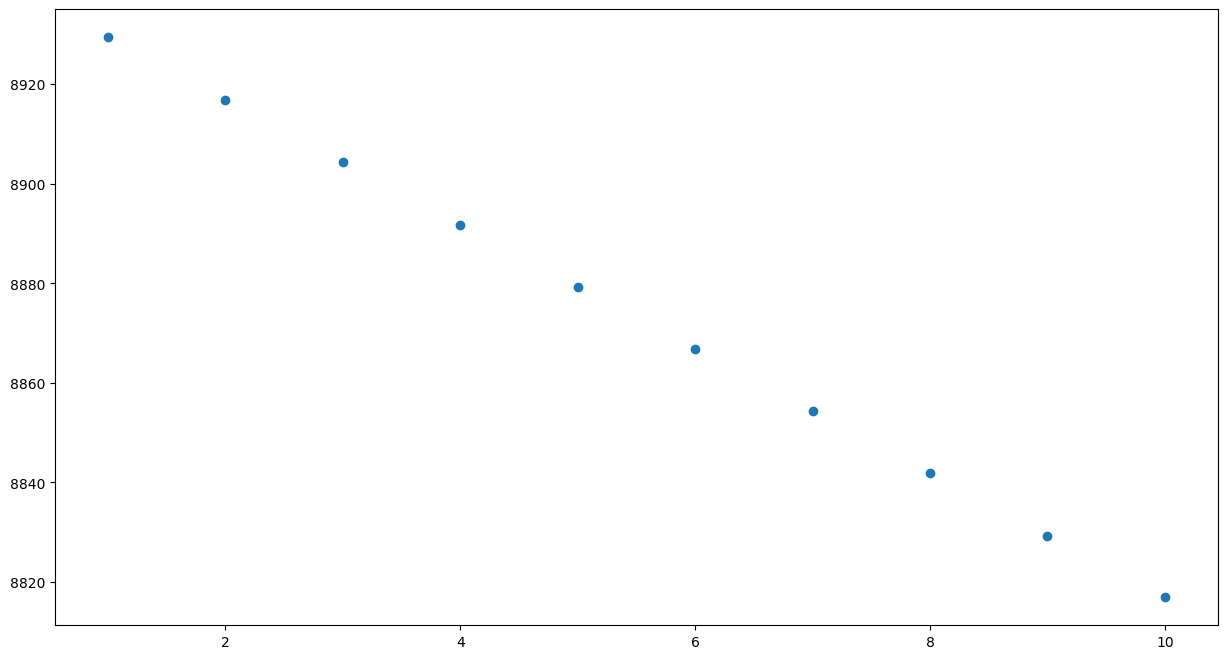

In [18]:
fig, ax = plt.subplots(figsize = (15,8))
ax.scatter(ns, rhos)
plt.show()

In [ ]:
traj_id = 0
seq = "ATCTCGAGATCTCG"
record = snbr.MutationRecord(sequence=seq)

In [2]:
rhocom = snbr.RobustnessComputer('test', seq)

In [5]:
rhocom.compute_n_robustness(n_sim=1000, method="signature", n=2)

0.026

In [3]:
rhocom.compute_l_robustness(n_sim=1000, method="signature", eval_method="nonsynonymous", mutational_signature='SBS2', multiprocessing=True)

0.043

In [10]:
rhocom.trajs[5].show()

Trajectory ID: 5
Original Sequence: ATCTCGAGATCTCG
Sequence Length: 14
Number of Mutations: 1

Mutation Steps:
  Step 0: ATCTCGAGATCTCG	.	.	.	.
  Step 1: ATTTCGAGATCTCG	c.2C>T	p.S1F	T[C>T]T	.


In [5]:
record.sequence[1:-1]

'TCTCGAGATCTC'

In [59]:
traj = snbr.Trajectory(traj_id, record)
traj.autofill(method="signature", eval_method="max_length", maxlen=1)
traj.show()

Autofill completed
Trajectory ID: 0
Original Sequence: ATCTCGAGATCTCG
Sequence Length: 14
Number of Mutations: 1

Mutation Steps:
  Step 0: ATCTCGAGATCTCG	.	.	.	.
  Step 1: ATCTCGAGATCTTG	c.12C>T	.	T[C>T]G	.


In [2]:
traj.autofill(method="signature", eval_method="blosum", threshold=30)

Autofill completed


In [6]:
traj.show()

Trajectory ID: 0
Original Sequence: ATCTCGAGATCTCG
Sequence Length: 14
Number of Mutations: 1

Mutation Steps:
  Step 0: ATCTCGAGATCTCG	.	.	.	.
  Step 1: ATCTCGAGATCTTG	c.12C>T	.	T[C>T]G	.


In [3]:
traj.add_mutated_sequence(method="signature")

[MutationRecord(sequence=Seq('ATCTCGAGATCTCG'), hgvs_mrna='.', hgvs_aa='.', mut_type='.', note='.'),
 MutationRecord(sequence=Seq('ATCTCAAGATCTCG'), hgvs_mrna='c.5G>A', hgvs_aa='.', mut_type='T[C>T]G', note='.')]

In [29]:
snbr.mutate.mutate_seq_with_mutational_signature(seq)

MutInfo(new_seq='ATCTCGAGATCTTG', idx_target=12, hgvs_mrna='c.12C>T', mut_type='T[C>T]G', e=0)

In [3]:
traj.autofill()

autofill


In [1]:
import sinabro_v2 as snbr

seq = "ATCTCGAGATCTCG"

#snbr.mutate._mutate_seq_with_mut_type_basic(seq, "T[C>T]")
#snbr.mutate._mutate_seq_with_mut_type_reverse(seq, "T[C>T]")
snbr.mutate._mutate_seq_with_mut_type_both(seq, "T[C>T]")

MutInfo(new_seq='ATCTCAAGATCTCG', idx_target=5, hgvs_mrna='c.5G>A', mut_type='[G>A]A', e=0)

In [135]:
import sinabro_v2 as snbr

seq = "ATCTCGAGATCTCG"

snbr.mutate.mutate_seq_with_mutational_signature(seq)

MutInfo(new_seq='ATCTTGAGATCTCG', idx_target=4, hgvs_mrna='c.4C>T', mut_type='T[C>T]G', e=0)

In [2]:
seq = "ATCTCTCTCG"

snbr.mutate._mutate_seq_with_mut_type_basic(seq, "T[C>T]")

MutInfo(new_seq='ATCTCTTTCG', idx_target=6, hgvs_mrna='c.7C>T', mut_type='T[C>T]', e=0)

In [44]:
seq = snbr.utils.generate_random_sequence(5)

print(seq)
snbr.mutate.random_single_substitution(seq)

ATGGC


MutInfo(new_seq=Seq('ATGCC'), idx_target=3, hgvs_mrna='c.3G>C', mut_type='[G>C]', e=0)

In [2]:
codon1 = snbr.utils.generate_random_sequence(3)
codon2 = snbr.utils.generate_random_sequence(3)

snbr.utils.is_codon_synonymous(codon1, codon2)

False

NameError: name 're' is not defined

In [ ]:
### Helper function

In [ ]:
def _is_codon_synonymous(codon1, codon2):
    from Bio.Data import CodonTable
    
    codon_table = CodonTable.standard_dna_table.forward_table
    codon_table["TAA"] = "*"
    codon_table["TAG"] = "*"
    codon_table["TGA"] = "*"
    
    if codon_table[codon1] == codon_table[codon2]:
        return True
    else:
        return False

In [7]:
from Bio.Data import CodonTable

def is_codon_synonymous(codon1, codon2):
    """
    Determine if two DNA codons are synonymous, i.e., they code for the same amino acid.

    Parameters:
        codon1 (str): The first codon (e.g., "ATG").
        codon2 (str): The second codon (e.g., "ATA").

    Returns:
        bool: True if both codons encode the same amino acid, False otherwise.

    Raises:
        ValueError: If either codon is invalid or not present in the standard codon table.
    """
    # Create a copy of the standard codon table mapping (without stop codons).
    codon_table = CodonTable.standard_dna_table.forward_table.copy()
    # Manually add stop codons mapping to "*" (stop signal).
    codon_table.update({"TAA": "*", "TAG": "*", "TGA": "*"})

    # Convert codons to uppercase to ensure consistency.
    codon1 = codon1.upper()
    codon2 = codon2.upper()

    try:
        # Check if both codons translate to the same amino acid.
        return codon_table[codon1] == codon_table[codon2]
    except KeyError as e:
        # Raise a clearer error if a codon is not valid.
        raise ValueError(f"Invalid codon provided: {e.args[0]}")

In [9]:
from Bio.Align import PairwiseAligner
from Bio.Align import substitution_matrices

def compute_alignment(seq1, seq2, mode="global", gap_open=-10, gap_extend=-0.5, matrix_name="BLOSUM62"):
    """
    Perform an alignment between two amino acid sequences.
    
    Parameters:
        seq1 (str): The first amino acid sequence.
        seq2 (str): The second amino acid sequence.
        mode (str): Alignment mode ('global', 'local', 'semiglobal', etc.). Default is "global".
        gap_open (float): Gap opening penalty. Default is -10.
        gap_extend (float): Gap extension penalty. Default is -0.5.
        matrix_name (str): Name of the substitution matrix to use. Default is "BLOSUM62".
        
    Returns:
        best_alignment: The alignment result with the highest score.
    """
    # Create and configure the PairwiseAligner object
    aligner = PairwiseAligner()
    aligner.mode = mode
    aligner.open_gap_score = gap_open
    aligner.extend_gap_score = gap_extend

    # Load and apply the substitution matrix
    substitution_matrix = substitution_matrices.load(matrix_name)
    aligner.substitution_matrix = substitution_matrix

    # Perform the alignment and return the best (highest scoring) alignment
    alignments = aligner.align(seq1, seq2)
    best_alignment = alignments[0]
    return best_alignment


def compute_distance(seq1, seq2):
    """
    Compute the distance between two sequences based on their alignment scores.
    
    This function calculates the maximum possible alignment score for seq1 (self-alignment)
    and the best alignment score between seq1 and seq2. The distance is defined as the
    difference between the maximum self-alignment score and the alignment score of seq1 and seq2.
    
    Parameters:
        seq1 (str): The first amino acid sequence.
        seq2 (str): The second amino acid sequence.
        
    Returns:
        float: The computed distance.
    """
    # Compute the maximum possible alignment score (self-alignment of seq1)
    self_alignment = compute_alignment(seq1, seq1)
    max_score = self_alignment.score

    # Compute the best alignment score between seq1 and seq2
    best_alignment = compute_alignment(seq1, seq2)
    best_score = best_alignment.score

    # Calculate the distance as the difference between the maximum score and the best alignment score
    distance = max_score - best_score
    return distance


In [32]:
from Bio.Seq import Seq
import numpy as np
import pandas as pd

# Generate a list of all possible trinucleotides as BioPython Seq objects using list comprehension
dna_bases = ["A", "C", "G", "T"]
trinucleotides = [Seq(a + b + c) for a in dna_bases for b in dna_bases for c in dna_bases]

# Create a dictionary for fast lookup of trinucleotide indices
trint_dict = {str(trinuc): i for i, trinuc in enumerate(trinucleotides)}

def make_full_mutational_signature(
    input_file_path: str,
    column: str = None,
    strand_bias: float = 0.5
) -> np.ndarray:
    """
    Generate a full mutational signature matrix from an SBS (single base substitution) file.
    
    This function reads an SBS file where each mutation type is indexed, and constructs a 4x64 
    matrix representing the mutational signature based on trinucleotide contexts. For each mutation type,
    the function extracts the forward trinucleotide context and its reverse complement, then assigns
    the mutation percentage (adjusted by strand bias) to the corresponding positions in the matrix.
    
    Parameters:
        input_file_path (str): The file path to the SBS file (tab-separated, with headers and index).
        column (str, optional): The column name from the SBS file to use. If None, the first column is used.
        strand_bias (float, optional): The factor to apply to the mutation percentage (default is 0.5).
        
    Returns:
        np.ndarray: A 2D numpy array (4x64) representing the full mutational signature.
    """
    # Read the SBS file into a pandas DataFrame
    sbs = pd.read_csv(input_file_path, sep="\t", index_col=0, header=0)

    # Select the column to use for mutational percentages; default to the first column if not provided
    if column is None:
        column = sbs.columns[0]

    # Initialize a 4x64 numpy array with zeros for the mutational signature matrix
    full_mutational_signature = np.zeros((4, 64))
    
    # Get the list of mutation types from the DataFrame index
    mut_types = list(sbs.index)
    
    for mut_type in mut_types:
        # Extract the trinucleotide context for the forward strand based on specific indices
        trinucleotide_f = f"{mut_type[0]}{mut_type[2]}{mut_type[6]}"
        # Calculate the reverse complement of the forward trinucleotide context
        trinucleotide_r = str(Seq(trinucleotide_f).reverse_complement())
        
        # Get the mutated nucleotide for the forward mutation
        changed_nt_f = mut_type[4]
        # Calculate the complement of the mutated nucleotide for the reverse mutation
        changed_nt_r = str(Seq(changed_nt_f).complement())

        # Calculate the mutation percentage adjusted by strand bias
        mut_type_percentage = strand_bias * sbs.loc[mut_type, column]

        # Determine the index for the mutated nucleotide in the list of DNA bases
        i1 = dna_bases.index(changed_nt_f)
        # Determine the index for the forward trinucleotide in the list of trinucleotides
        j1 = trinucleotides.index(Seq(trinucleotide_f))
        # Determine the index for the complement nucleotide in the list of DNA bases
        i2 = dna_bases.index(changed_nt_r)
        # Determine the index for the reverse complement trinucleotide in the list of trinucleotides
        j2 = trinucleotides.index(Seq(trinucleotide_r))
        
        # Assign the adjusted mutation percentage to both forward and reverse contexts in the matrix
        full_mutational_signature[i1, j1] = mut_type_percentage
        full_mutational_signature[i2, j2] = mut_type_percentage

    return full_mutational_signature

In [31]:
def get_trinucleotides(seq: str) -> list:
    """
    Extract trinucleotides from a sequence using list comprehension.
    
    Parameters:
        seq (str): Input nucleotide sequence.
        
    Returns:
        List[str]: List of trinucleotides (each of length 3).
    """
    return [seq[i - 1: i + 2] for i in range(1, len(seq) - 1)]

In [20]:
def generate_random_sequence(length, gc=0.5):
    dna = ["A", "C", "G", "T"]
    seq = Seq("".join(
        np.random.choice(
            dna, 
            length, 
            p=0.5*np.array([1-gc, gc, gc, 1-gc])
            )
        )
    )
    
    return seq

In [38]:
test_seq = generate_random_sequence(3*2000+2)
trint_list = get_trinucleotides(test_seq) 

#[trint_dict[trint] for trint in trint_list]

In [24]:
test_seq = generate_random_sequence(3*2000+2)
test_seq

Seq('AAGTGATTTGTCCCCCTCGCATAGGTGCATTGGGGCTACGATAATACCTTATTG...TCA')

In [46]:
# Create a dictionary for fast lookup of trinucleotide indices
trint_dict = {str(trinuc): i for i, trinuc in enumerate(trinucleotides)}

def compute_mut_prob_matrix(seq, full_mutational_signature):
    """
    Compute the mutation probability matrix for a given sequence based on a full mutational signature.
    
    This function constructs a trinucleotide context vector from the input sequence and maps each trinucleotide
    (for positions with both a left and right neighbor) to its corresponding index in the global 'trinucleotides' list.
    It then builds a probability matrix (of shape 4 x len(seq)) using the provided full_mutational_signature matrix.
    The matrix is normalized by the total sum of its elements.
    
    Parameters:
        seq (str): The input nucleotide sequence.
        full_mutational_signature (np.ndarray): A 2D numpy array representing the full mutational signature (4 x 64).
        
    Returns:
        np.ndarray: A normalized mutation probability matrix with shape (4, len(seq)).
    """
    # Extract trinucleotides using list comprehension (ignoring the first and last nucleotide)
    trint_list = [str(seq[i - 1: i + 2]) for i in range(1, len(seq) - 1)]
    
    # Create the trinucleotide vector with placeholders for the first and last positions
    trint_vector = ["-"] + trint_list + ["-"]
    
    # Create the trinucleotide type vector using the precomputed dictionary,
    # with -1 as placeholder values for positions without a trinucleotide context
    trint_type_vector = [-1] + [trint_dict[trint] for trint in trint_list] + [-1]
    
    # Initialize the probability matrix (4 rows for nucleotides, columns equal to sequence length)
    P_before_norm = np.zeros((4, len(seq)))
    
    # Vectorized assignment for positions where a trinucleotide context exists (positions 1 to len(seq)-2)
    valid_indices = np.array(trint_type_vector[1:-1])
    P_before_norm[:, 1:-1] = full_mutational_signature[:, valid_indices]
    
    # Normalize the matrix by the total sum of its elements
    S = np.sum(P_before_norm)
    P = P_before_norm / S
    
    return P


In [40]:
sbs_file = "/mnt/c/Users/CEEL-PC-005/Desktop/Joon/storage_effect/gsespy/COSMIC_v3.3.1_SBS_GRCh38.txt"


fms = make_full_mutational_signature(
    input_file_path = sbs_file,
    column = "SBS2"
)

In [41]:
compute_mut_prob_matrix(test_seq, fms)

array([[0.00000000e+00, 1.32082156e-06, 0.00000000e+00, ...,
        2.74495384e-07, 3.34080561e-07, 0.00000000e+00],
       [0.00000000e+00, 1.64151486e-06, 1.28951665e-06, ...,
        6.41037123e-07, 1.21931203e-18, 0.00000000e+00],
       [0.00000000e+00, 8.31628389e-07, 3.34299065e-07, ...,
        5.22691808e-07, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 5.19599357e-07, ...,
        0.00000000e+00, 3.17130483e-09, 0.00000000e+00]])

In [15]:
sbs_file = "/mnt/c/Users/CEEL-PC-005/Desktop/Joon/storage_effect/gsespy/COSMIC_v3.3.1_SBS_GRCh38.txt"


fms = make_full_mutational_signature(
    input_file_path = sbs_file,
    column = "SBS2"
)

In [47]:
import os
import time
import math
from typing import Union
from Bio.Seq import Seq, MutableSeq

class MutInfo:
    def __init__(
        self, 
        new_seq: Union[str, Seq, MutableSeq], 
        idx_target: int, 
        hgvs_mrna: str,
        mut_type: str,
        e: int
    ) -> None:
        """
        Initialize a MutInfo object containing mutation details.
        
        Parameters:
            new_seq (Union[str, Seq, MutableSeq]): The mutated sequence.
            idx_target (int): The index of the mutated nucleotide.
            hgvs_mrna (str): HGVS notation for the mutation.
            mut_type (str): Mutation type description.
            e (int): Error code (0 for success).
        """
        self.new_seq = new_seq
        self.idx_target = idx_target
        self.hgvs_mrna = hgvs_mrna
        self.mut_type = mut_type
        self.e = e

def mutate_seq_with_mutational_signature(
    seq: Union[str, Seq, MutableSeq],
    start: int = None,
    end: int = None,
    mutational_signature: str = "SBS1",
    cosmic_version: float = 3.3,
    genome_ref: str = "GRCh37",
    custom_signature_path: str = None,
    column: str = None,
    strand_bias: float = 0.5
) -> tuple[Union[str, Seq, MutableSeq], int, str, int]:
    """
    Mutate a nucleotide sequence based on a specified mutational signature.
    
    This function mutates the input sequence using a full mutational signature matrix derived from either a custom file
    or pre-defined COSMIC signatures. It computes a mutation probability matrix for the sequence, selects a mutation 
    site probabilistically, constructs HGVS notation for the mutation, and applies the mutation to the sequence.
    
    Parameters:
        seq (Union[str, Seq, MutableSeq]): The input nucleotide sequence.
        start (int, optional): Start position for mutation (default is 0 if not provided).
        end (int, optional): End position for mutation (default is len(seq)-1 if not provided).
        mutational_signature (str): Mutational signature to use ('SBS1', 'SBS2', ... or 'custom').
        cosmic_version (float): COSMIC version number to use for pre-defined signatures.
        genome_ref (str): Genome reference to use for pre-defined signatures.
        custom_signature_path (str, optional): File path for custom signature if 'custom' is selected.
        column (str, optional): Column name in the signature file to use.
        strand_bias (float): Factor to apply for strand bias in mutational signature.
        
    Returns:
        tuple[Union[str, Seq, MutableSeq], int, str, int]: A tuple containing the mutated sequence, target index, 
        HGVS notation, mutation type, and error code (0 for success).
    """
    # Convert input sequence to MutableSeq and record original data type
    if isinstance(seq, str):
        seq = MutableSeq(seq)
        data_type = "str"
    elif isinstance(seq, Seq):
        seq = MutableSeq(str(seq))
        data_type = "Seq"
    elif isinstance(seq, MutableSeq):
        data_type = "MutableSeq"
    else:
        raise TypeError("seq should be a string, Seq, or MutableSeq object")
    
    # Validate and set start and end indices (currently unused in mutation; consider using these to restrict mutation region)
    if start is not None:
        if not isinstance(start, int):
            raise TypeError("start should be an integer object")
    else:
        start = 0
        
    if end is not None:
        if not isinstance(end, int):
            raise TypeError("end should be an integer object")
    else:
        end = len(seq) - 1

    # Define available mutational signatures
    signatures = [
        "SBS1", "SBS2", "SBS3", "SBS4", "SBS5", "SBS6", "SBS7a", "SBS7b", 
        "SBS7c", "SBS7d", "SBS8", "SBS9", "SBS10a", "SBS10b", "SBS10c", 
        "SBS10d", "SBS11", "SBS12", "SBS13", "SBS14", "SBS15", "SBS16", 
        "SBS17a", "SBS17b", "SBS18", "SBS19", "SBS20", "SBS21", "SBS22", 
        "SBS23", "SBS24", "SBS25", "SBS26", "SBS27", "SBS28", "SBS29", 
        "SBS30", "SBS31", "SBS32", "SBS33", "SBS34", "SBS35", "SBS36", 
        "SBS37", "SBS38", "SBS39", "SBS40", "SBS41", "SBS42", "SBS43", 
        "SBS44", "SBS45", "SBS46", "SBS47", "SBS48", "SBS49", "SBS50", 
        "SBS51", "SBS52", "SBS53", "SBS54", "SBS55", "SBS56", "SBS57",
        "SBS58", "SBS59", "SBS60", "SBS84", "SBS85", "SBS86", "SBS87", 
        "SBS88", "SBS89", "SBS90", "SBS91", "SBS92", "SBS93", "SBS94", 
        "SBS95"
    ]

    # Load full mutational signature matrix
    if mutational_signature == "custom":
        if custom_signature_path is None:
            raise ValueError("custom_signature_path must be provided")
        else:
            full_mutational_signature = make_full_mutational_signature(
                input_file_path=custom_signature_path,
                column=column,
                strand_bias=strand_bias
            )
    elif mutational_signature in signatures:
        dir_name = os.path.dirname(__file__)
        tokens = [
            "../../cosmic_signatures/COSMIC_v",
            str(cosmic_version), ".1_SBS_",
            genome_ref, ".txt"
        ]
        signature_file = "".join(tokens)
        signature_file_path = os.path.join(dir_name, signature_file)
        full_mutational_signature = make_full_mutational_signature(
            input_file_path=signature_file_path,
            column=mutational_signature,
            strand_bias=strand_bias
        )
    else:
        raise ValueError("signature must be SBSXX or custom")

    # Compute mutation probability matrix for the sequence
    P = compute_mut_prob_matrix(seq, full_mutational_signature)

    # Check if there are any valid mutation probabilities
    num_nonzero = np.count_nonzero(P)
    if not num_nonzero:
        return MutInfo(MutableSeq(""), -1, "", "", 1)
    
    # Seed the random number generator using current time
    seed1 = time.time()
    seed2 = (seed1 - int(seed1)) * (10**7)
    np.random.seed(int(seed1 + seed2))
    
    # Randomly select a mutation site based on the probability matrix P (flattened in Fortran order)
    idx_flat = np.random.choice(len(seq) * 4, p=P.flatten("F"))
    idx_base = idx_flat % 4
    idx_target = idx_flat // 4  # Using integer division instead of math.floor

    # Note: 'dna_bases' should be defined globally (e.g., dna_bases = ["A", "C", "G", "T"])
    # Construct HGVS notation and mutation type based on the target nucleotide
    if str(seq[idx_target]) not in ["C", "T"]:
        # For nucleotides other than C or T, use complementary representation
        hgvs_mrna_tokens = [
            "c.", str(idx_target),
            str(seq[idx_target]), ">",
            dna_bases[idx_base]
        ]
        mut_type_tokens = [
            str(Seq(seq[idx_target+1]).complement()), "[", 
            str(Seq(seq[idx_target]).complement()), ">", 
            str(Seq(dna_bases[idx_base]).complement()), "]",
            str(Seq(seq[idx_target-1]).complement())
        ]
        hgvs_mrna = "".join(hgvs_mrna_tokens)
        mut_type = "".join(mut_type_tokens)
    else:
        # For C or T, use the original bases
        hgvs_mrna_tokens = [
            "c.", str(idx_target),
            str(seq[idx_target]), ">",
            dna_bases[idx_base]
        ]
        mut_type_tokens = [
            str(seq[idx_target-1]), "[",
            str(seq[idx_target]), ">",
            dna_bases[idx_base], "]",
            str(seq[idx_target+1])    
        ]
        hgvs_mrna = "".join(hgvs_mrna_tokens)
        mut_type = "".join(mut_type_tokens)
        
    # Apply the mutation to the sequence
    seq[idx_target] = dna_bases[idx_base]

    # Convert sequence back to the original data type before returning
    if data_type == "str":
        return MutInfo(str(seq), idx_target, hgvs_mrna, mut_type, 0)
    elif data_type == "Seq":
        return MutInfo(Seq(seq), idx_target, hgvs_mrna, mut_type, 0)
    elif data_type == "MutableSeq":
        return MutInfo(seq, idx_target, hgvs_mrna, mut_type, 0)


In [52]:
test_seq = generate_random_sequence(3*5+2)
#print(test_seq)

rlt = mutate_seq_with_mutational_signature(
    seq = test_seq,
    mutational_signature = "custom",
    custom_signature_path = sbs_file,
    column = "SBS2"
)

#print(rlt.new_seq)
print(rlt.mut_type)
print(rlt.hgvs_mrna)

ACCCCACACGCTACGGC
ACCCCACACGCCACGGC
C[T>C]A
c.11T>C


In [50]:
rlt.new_seq

Seq('CTATAGATTCGGTTGCTCTCGGTATCTAAATAGTGACAATGCTAAGGCGCCGAG...TGT')

In [ ]:
class Trajectory():    
    def __init__(self, id, data, note="."):
        self._id = id
        self._data = []
        if data is None:
            raise ValueError("data must not be None")
        elif isinstance(data, str):
            self._original_seq = Seq(data)
        elif isinstance(data, Seq):
            self._original_seq = data
        elif isinstance(data, MutableSeq):
            self._original_seq = Seq(data)
        else:
            raise TypeError(
                "data should be a string, Seq, or MutableSeq object"
            )
        self._data.append(self._original_seq)
        self._seq_length = len(self._original_seq)
        self._hgvs_mrnas = ["."]
        self._hgvs_aa = ["."]
        self._mut_types = ["."]
        self._notes = [note]
        #self._scores = ["."]        
        self._length = 0
    
    def show(self, verbose= True, noseq=False, show_idx=False):
        print(f"ID: {self._id}")
        print(f"Trajectory length: {self._length}")

        if verbose:
            if noseq:
                print(f"")
                print(f"HGVS_mRNA\tHGVS_Protein\tMutation_Type\tNote")
                for i in range(self._length+1):
                    line_tokens = [
                        self._hgvs_mrnas[i],
                        self._hgvs_aa[i],
                        self._mut_types[i],
                        self._notes[i] 
                    ]
                    line = "\t".join(line_tokens)
                    print(line)
            else:
                if self._seq_length > 35:
                    pass
                else:
                    sp1 = " "*(self._seq_length-5)
                    sp2 = " "*int(math.floor((self._seq_length-2)/10))
                    sp3 = " "*int(math.floor(((self._seq_length-2)/3)/10)+2)
                    sp4 = "   "

                    print(f"")
                    header_tokens = [
                        "Sequence", sp1,
                        "HGVS_mRNA", sp2,
                        "HGVS_Protein", sp3,
                        "Mutation_Type", sp4,
                        "Note"
                    ]
                    header = "".join(header_tokens)
                    print(header)
                    if show_idx:
                        idx_line_1 = "+123456789_123456789_123456789_123+"
                        idx_line_2 = "+1__2__3__4__5__6__7__8__9__0__1__+"
                        print(idx_line_1[0:self._seq_length])
                        print(idx_line_2[0:self._seq_length])
                    else:
                        pass
                    for i in range(self._length+1):
                        sp1 = "   "
                        sp2 = " "*(12-len(self._hgvs_mrnas[i]))
                        sp3 = " "*(15-len(self._hgvs_aa[i]))
                        sp4 = " "*(16-len(self._mut_types[i]))
                        line_tokens = [
                            str(self._data[i]), sp1,
                            self._hgvs_mrnas[i], sp2,
                            self._hgvs_aa[i], sp3,
                            self._mut_types[i], sp4,
                            self._notes[i] 
                        ]
                        line = "".join(line_tokens)
                        print(line)
        else:
            pass

    def append(self, seq, hgvs_mrna=".", mut_type=".", note="."):
        if seq is None:
            raise ValueError("seq must not be None")
        elif isinstance(seq, str):
            self._data.append(Seq(seq))
        elif isinstance(seq, Seq):
            self._data.append(seq)
        elif isinstance(seq, MutableSeq):
            self._data.append(Seq(seq))
        else:
            raise TypeError(
                "data should be a string, Seq, or MutableSeq object"
            )
        self._hgvs_mrnas.append(hgvs_mrna)
        self._mut_types.append(mut_type)
        self._notes.append(note)

        return self._data

    def pop(self):
        last_seq = self._data.pop()
        last_hgvs_mrna = self._hgvs_mrnas.pop()
        last_hgvs_aa = self._hgvs_aa.pop()
        last_mut_type = self._mut_types.pop()
        last_note = self._notes.pop()
        self._length = self._length-1

        return self._data
        
    def add_mutated_sequence(self, **kwargs) -> list:
        method = kwargs["method"]
        if method == "random":
            # check passed kwargs and assign accordingly
            if "note" in kwargs.keys():
                note = kwargs["note"]
            else:
                note = "."
            
            if "start" in kwargs.keys():
                if kwargs["start"] < 0:
                    start = self._seq_length+kwargs["start"]
                else:
                    start = kwargs["start"]
            else:
                start = 0

            if "end" in kwargs.keys():
                if kwargs["end"] < 0:
                    end = self._seq_length+kwargs["end"]
                elif kwargs["end"] >= start:
                    end = kwargs["end"]-1
                else:
                    raise ValueError(
                    "end should be equal or greater than start"
                )
            else:
                end = self._seq_length-1

            last_seq = self._data[-1]
            mutinfo = random_single_substitution(
                last_seq,
                start=start,
                end=end
                )
            if not mutinfo.e:
                self.append(mutinfo.new_seq, 
                            hgvs_mrna=mutinfo.hgvs_mrna, 
                            mut_type=mutinfo.mut_type,
                            note=note)
                self._length = self._length+1
            else:
                pass
        elif method == "mut_type":
            mut_type = kwargs["mut_type"]
            if "note" in kwargs.keys():
                note = kwargs["note"]
            else:
                note = "."
            if "strand" in kwargs.keys():
                strand = kwargs["strand"]
            else:
                strand = "both"
            if "start" in kwargs.keys():
                if kwargs["start"] < 0:
                    start = self._seq_length+kwargs["start"]
                else:
                    start = kwargs["start"]
            else:
                start = 0

            if "end" in kwargs.keys():
                if kwargs["end"] < 0:
                    end = self._seq_length+kwargs["end"]
                elif kwargs["end"] >= start:
                    end = kwargs["end"]-1
                else:
                    raise ValueError(
                    "end should be equal or greater than start"
                )
            else:
                end = self._seq_length-1
            last_seq = self._data[-1]
            mutinfo = mutate_seq_with_mut_type(
                last_seq,
                mut_type=mut_type,
                strand=strand,
                start=start,#1,#1,
                end=end#self._seq_length-2
                )
            if not mutinfo.e:
                self.append(mutinfo.new_seq, 
                            hgvs_mrna=mutinfo.hgvs_mrna, 
                            mut_type=mutinfo.mut_type,
                            note=note)
                self._length = self._length+1
            else:
                self._notes[-1] = "No_Motif"
        elif method == "mut_types":
            mut_types = kwargs["mut_types"]
            mut_type_probs = kwargs["mut_type_probs"]
            if "note" in kwargs.keys():
                note = kwargs["note"]
            else:
                note = "."
            if "strand" in kwargs.keys():
                strand = kwargs["strand"]
            else:
                strand = "both"
            if "start" in kwargs.keys():
                if kwargs["start"] < 0:
                    start = self._seq_length+kwargs["start"]
                else:
                    start = kwargs["start"]
            else:
                start = 0

            if "end" in kwargs.keys():
                if kwargs["end"] < 0:
                    end = self._seq_length+kwargs["end"]
                elif kwargs["end"] >= start:
                    end = kwargs["end"]-1
                else:
                    raise ValueError(
                    "end should be equal or greater than start"
                )
            else:
                end = self._seq_length-1
            last_seq = self._data[-1]
            mutinfo = mutate_seq_with_mut_types(
                last_seq,
                mut_types=mut_types,
                mut_type_probs=mut_type_probs,
                strand=strand,
                start=start,#1,#1,
                end=end#self._seq_length-2
                )
            if not mutinfo.e:
                self.append(mutinfo.new_seq, 
                            hgvs_mrna=mutinfo.hgvs_mrna, 
                            mut_type=mutinfo.mut_type,
                            note=note)
                self._length = self._length+1
            else:
                self._notes[-1] = "No_Motif"
        elif method == "signature":
            mutational_signature = kwargs["mutational_signature"]
            if "cosmic_version" in kwargs.keys():
                cosmic_version = kwargs["cosmic_version"]
            else:
                cosmic_version = 3.3
            if "genome_ref" in kwargs.keys():
                genome_ref = kwargs["genome_ref"]
            else:
                genome_ref = "GRCh37"
            if "custom_signature_path" in kwargs.keys():
                custom_signature_path = kwargs["custom_signature_path"]
            else:
                custom_signature_path =None
            if "column" in kwargs.keys():
                column = kwargs["column"]
            else:
                column = None
            if "strand_bias" in kwargs.keys():
                strand_bias = kwargs["strand_bias"]
            else:
                strand_bias = 0.5
            if "note" in kwargs.keys():
                note = kwargs["note"]
            else:
                note = "."

            last_seq = self._data[-1]
            mutinfo = mutate_seq_with_mutational_signature(
                last_seq,
                mutational_signature=mutational_signature,
                cosmic_version=cosmic_version,
                genome_ref=genome_ref,
                custom_signature_path=custom_signature_path,
                column=column,
                strand_bias=strand_bias
            )
            if not mutinfo.e:
                self.append(mutinfo.new_seq, 
                            hgvs_mrna=mutinfo.hgvs_mrna, 
                            mut_type=mutinfo.mut_type,
                            note=note)
                self._length = self._length+1
            else:
                pass
        else:
            raise ValueError(
                "method must be either random, motif, or signature"
            )

        return self._data

    def autofill(
        self, 
        condition: str = "max_length", 
        max_length: int = 10,  
        **kwargs
        ):
        method = kwargs['method']
        if "start" in kwargs.keys():
            if kwargs["start"] < 0:
                start = self._seq_length+kwargs["start"]
            else:
                start = kwargs["start"]
        else:
            start = 0
        if condition == "max_length":
            for _ in range(max_length):
                last_seq = self._data[-1]
                self.add_mutated_sequence(**kwargs)

                if self._notes[-1] == "No_Motif":
                    break

                curr_seq = self._data[-1]
                prev_seq = self._data[-2]
                
                idx_target = _get_idx_from_hgvs_mrna(
                    self._hgvs_mrnas[-1], 
                    offset=start
                    )

                new_codon = _get_codon(curr_seq, idx_target, start)
                old_codon = _get_codon(prev_seq, idx_target, start)                            
                    
                if _is_codon_synonymous(new_codon, old_codon):
                    self._hgvs_aa.append(".")
                else:
                    pos_aa = _get_pos_aa(idx_target)

                    new_aa = _get_amino_acid_from_codon(new_codon, three=True)
                    old_aa = _get_amino_acid_from_codon(old_codon, three=True)

                    self._hgvs_aa.append(f"p.{pos_aa}{old_aa}>{new_aa}")

        elif condition == "nonsynonymous": 
            if method == "random": 
                pass
            elif method == "mut_type": 
                pass
            elif method == "mut_types":
                pass
            elif method == "signature":
                pass
            else:
                raise ValueError(
                    "condition must be either max_length or nonsynonymous"
                )
            stop_flag = False
            while not stop_flag:
                last_seq = self._data[-1]
                self.add_mutated_sequence(**kwargs)

                if self._notes[-1] == "No_Motif":
                    break

                curr_seq = self._data[-1]
                prev_seq = self._data[-2]

                idx_target = _get_idx_from_hgvs_mrna(
                    self._hgvs_mrnas[-1], 
                    offset=start
                    )
                
                print(self._hgvs_mrnas[-1])
                new_codon = _get_codon(curr_seq, idx_target, start)
                old_codon = _get_codon(prev_seq, idx_target, start)

                print(f"{idx_target} {old_codon} {new_codon}")
 
                if _is_codon_synonymous(new_codon, old_codon):
                    self._hgvs_aa.append(".")
                else:
                    pos_aa = _get_pos_aa(idx_target)

                    new_aa = _get_amino_acid_from_codon(new_codon, three=True)
                    old_aa = _get_amino_acid_from_codon(old_codon, three=True)

                    self._hgvs_aa.append(f"p.{pos_aa}{old_aa}>{new_aa}")
                    stop_flag = True
        elif condition == "evaluation":
            if method == "random": 
                pass
            elif method == "mut_type": 
                pass
            elif method == "signature":
                pass
            else:
                raise ValueError(
                    "condition must be either max_length or nonsynonymous"
                )

            if "measure" in kwargs.keys():
                measure = kwargs["measure"]
            else:
                raise ValueError(
                        "measure must be given"
                    )

            if measure == "blastp":
                std_seq = self._data[0]
                std_seq = std_seq[1:len(std_seq)-1]
                std_pp_seq = std_seq.translate()

                record = SeqRecord(std_pp_seq, id="stdseq", description="")
                SeqIO.write(record, "tmp_std_seq.fa", "fasta")

                ori_score = subprocess.run(
                    [
                        "blastp",
                        "-subject", "tmp_std_seq.fa",
                        "-query", "tmp_std_seq.fa",
                        "-outfmt", "6 bitscore"
                    ],
                    stdout=subprocess.PIPE
                ).stdout.decode("utf-8")
                ori_score = float(ori_score.replace("\n", "0"))  
                self._notes[0] = str(ori_score)

            stop_flag = False
            while not stop_flag:
                last_seq = self._data[-1]
                self.add_mutated_sequence(**kwargs)

                curr_seq = self._data[-1]
                prev_seq = self._data[-2]

                idx_target = _get_idx_from_hgvs_mrna(
                    self._hgvs_mrnas[-1], 
                    offset=1
                    )

                new_codon = _get_codon(curr_seq, idx_target)
                old_codon = _get_codon(prev_seq, idx_target)
 
                if _is_codon_synonymous(new_codon, old_codon):
                    self._hgvs_aa.append(".")
                else:
                    pos_aa = _get_pos_aa(idx_target)

                    new_aa = _get_amino_acid_from_codon(new_codon, three=True)
                    old_aa = _get_amino_acid_from_codon(old_codon, three=True)

                    self._hgvs_aa.append(f"p.{pos_aa}{old_aa}>{new_aa}")
                stop_flag, rlt_score = get_stop_condition(
                    curr_seq, 
                    ori_score, 
                    **kwargs
                    )                
                self._notes[-1] = rlt_score
            
            subprocess.run(["rm", "tmp_std_seq.fa"])
            subprocess.run(["rm", "tmp_cur_seq.fa"])
            
        else:
            raise ValueError(
                "condition must be either max_length or nonsynonymous"
            )

        return self._data

    def save(self, output_dir_path, prefix=None, suffix=None):
        records = []
        for i in range(self._length+1):
            desc_tokens = [
                self._hgvs_mrnas[i], 
                self._hgvs_aa[i],
                self._mut_types[i],
                self._notes[i]
            ]

            description = ";".join(desc_tokens)
            if isinstance(self._data[i], str):
                seq = Seq(self._data[i])
            else:
                seq = self._data[i]
            record = SeqRecord(seq, id=self._id, description=description)
            records.append(record)

        if prefix:
            prefix = f"{prefix}_"
        else:
            prefix = ""

        if suffix:
            suffix = f"_{suffix}"
        else:
            suffix = ""

        file_name = f"{prefix}trajectory{suffix}.fa"
        output_path = os.path.join(output_dir_path, file_name)

        SeqIO.write(records, output_path, "fasta")

# Refactory Trajectory objects

In [12]:
from dataclasses import dataclass
from typing import Union
from Bio.Seq import Seq, MutableSeq

@dataclass
class MutationRecord:
    """
    Data class to store mutation record information.
    
    Attributes:
        sequence (Seq): The nucleotide sequence.
        hgvs_mrna (str): HGVS notation for mRNA.
        hgvs_aa (str): HGVS notation for amino acids.
        mut_type (str): Mutation type.
        note (str): Additional note.
    """
    sequence: Seq
    hgvs_mrna: str = "."
    hgvs_aa: str = "."
    mut_type: str = "."
    note: str = "."

class Trajectory:
    """
    Class to represent a trajectory of mutations.
    
    Attributes:
        _traj_id: Identifier for the trajectory.
        _original_seq (Seq): The original nucleotide sequence.
        _data (list): List of sequences (Seq objects) representing the trajectory.
        _seq_length (int): Length of the original sequence.
        _length (int): The number of mutations added.
    """
    def __init__(self, traj_id, record: MutationRecord, note="."):
        """
        Initialize the Trajectory with an initial MutationRecord.
        
        Args:
            traj_id: Identifier for the trajectory.
            record (MutationRecord): The initial mutation record.
            note (str): Additional note (unused in this context).
        
        Raises:
            ValueError: If the sequence in the record is None.
            TypeError: If the sequence type is invalid.
        """
        # Validate and convert the input mutation record
        valid_record = self._validate_and_convert_record(record)
        
        # Save the original sequence from the validated record
        self._original_seq = valid_record.sequence
        
        # Initialize trajectory attributes
        self._traj_id = traj_id
        self._data = [self._original_seq]  # List to store sequences over the trajectory
        self._seq_length = len(self._original_seq)
        self._length = 0

    def __str__(self) -> str:
        """
        Return a formatted string representing the trajectory details.
        """
        output = []
        output.append(f"Trajectory ID: {self._traj_id}")
        output.append(f"Original Sequence: {self._original_seq}")
        output.append(f"Sequence Length: {self._seq_length}")
        output.append(f"Number of Mutations: {self._length}")
        output.append("Mutation Steps:")
        for i, seq in enumerate(self._data):
            output.append(f"  Step {i}: {seq}")
        return "\n".join(output)

    def show(self, verbose: bool = True):
        """
        Display the trajectory details.
        
        Args:
            verbose (bool): If True, display detailed mutation steps.
        """
        # Print the trajectory header information
        print(f"Trajectory ID: {self._traj_id}")
        print(f"Original Sequence: {self._original_seq}")
        print(f"Sequence Length: {self._seq_length}")
        print(f"Number of Mutations: {self._length}")

        # If verbose is True, print each mutation step in detail
        if verbose:
            print("\nMutation Steps:")
            for i, seq in enumerate(self._data):
                # Here you could add more detailed info for each step if available
                print(f"  Step {i}: {seq}")

    def add_record(self, record: MutationRecord) -> list:
        """
        Append a new mutation record to the trajectory.
        
        Args:
            record (MutationRecord): A mutation record object containing the mutation details.
        
        Returns:
            list: The updated list of MutationRecord objects.
            
        Raises:
            ValueError: If record.sequence is None.
            TypeError: If record.sequence is not a valid type.
        """
        if record.sequence is None:
            raise ValueError("Sequence in the mutation record must not be None")
        
        # Validate and convert the mutation record.
        valid_record = self._validate_and_convert_record(record)
        self._records.append(valid_record)
        self._length += 1
        return self._records

    def remove_last_record(self) -> MutationRecord:
        """
        Remove the last mutation record from the trajectory.
        
        Returns:
            MutationRecord: The removed mutation record.
        
        Raises:
            IndexError: If attempting to remove the initial record.
        """
        if len(self._records) <= 1:
            raise IndexError("Cannot remove the initial record.")
        removed_record = self._records.pop()
        self._length -= 1
        return removed_record

    
    """
    Autofill related methods
    """
    def add_mutated_sequence(self, **kwargs):
        """
        Append a mutated sequence to the trajectory based on the specified mutation method.
        
        Parameters:
            **kwargs: Keyword arguments containing mutation parameters.
                Expected keys include:
                    - method (str): The mutation method to apply ("random", "mut_type", "mut_types", "signature").
                    - note (str, optional): Additional note for the mutation.
                    - ... (other method-specific parameters)
        
        Returns:
            list: The updated list of sequence records.
        
        Raises:
            ValueError: If an invalid mutation method is provided.
        """
        # Mapping of mutation method names to their corresponding functions.
        mutation_methods = {
            "random": self._apply_random_mutation,
            "mut_type": self._apply_mut_type_mutation,
            "mut_types": self._apply_mut_types_mutation,
            "signature": self._apply_signature_mutation
        }
        
        # Retrieve the mutation method name from keyword arguments.
        method_name = kwargs.get("method")
        if method_name not in mutation_methods:
            raise ValueError("Invalid mutation method")
        
        # Execute the corresponding mutation function with the provided parameters.
        mutinfo = mutation_methods[method_name](**kwargs)
        
        # Check if the mutation process was successful (error code is 0).
        if not mutinfo.e:
            # Append the new mutated sequence to the trajectory records.
            self.append(mutinfo.new_seq,
                        hgvs_mrna=mutinfo.hgvs_mrna,
                        mut_type=mutinfo.mut_type,
                        note=kwargs.get("note", "."))
        else:
            # Add error handling logic here if necessary.
            pass
    
        return self._data

    

    """
    Internal helper methods
    """
    def _validate_and_convert_record(self, record: MutationRecord) -> MutationRecord:
        """
        Validate and convert the sequence in the mutation record.
        
        Args:
            record (MutationRecord): A mutation record to validate.
        
        Returns:
            MutationRecord: The validated and converted mutation record.
            
        Raises:
            ValueError: If the sequence is None.
            TypeError: If the sequence is not a string, Seq, or MutableSeq.
        """
        seq = record.sequence
        if seq is None:
            raise ValueError("data must not be None")
        # Convert the sequence to a Seq object if it's a string or MutableSeq
        if isinstance(seq, (str, MutableSeq)):
            record.sequence = Seq(seq)
            return record
        elif isinstance(seq, Seq):
            return record
        else:
            raise TypeError("data should be a string, Seq, or MutableSeq object")




In [13]:
# Example usage:
if __name__ == "__main__":
    # Create an initial MutationRecord with a nucleotide sequence
    record = MutationRecord(sequence=Seq("ATGCGTAC"))
    
    # Initialize a Trajectory object using the record
    trajectory = Trajectory("traj_01", record)
    
    # Using __str__ method: printing the trajectory object calls __str__ automatically.
    print("Using __str__ method:")
    print(trajectory)
    
    print("\nUsing show() method:")
    trajectory.show()

Using __str__ method:
Trajectory ID: traj_01
Original Sequence: ATGCGTAC
Sequence Length: 8
Number of Mutations: 0
Mutation Steps:
  Step 0: ATGCGTAC

Using show() method:
Trajectory ID: traj_01
Original Sequence: ATGCGTAC
Sequence Length: 8
Number of Mutations: 0

Mutation Steps:
  Step 0: ATGCGTAC


In [10]:
record1 = MutationRecord(sequence=Seq("ATG"))
record2 = MutationRecord(sequence=Seq("CTG"))

print(record1.sequence)
print(record2.sequence)

record1.sequence = Seq("TTG")
print(record1.sequence)


ATG
CTG
TTG


In [ ]:
class Trajectory():
    def __init__(self, traj_id, record, note="."):
        valid_record = self._validate_and_convert_record(record)
        
        self._traj_id = traj_id
        self._data = []
        self._data.append(self._original_seq)
        self._seq_length = len(self._original_seq)
        self._length = 0

    def _validate_and_convert_record(self, record):
        seq = record.sequence
        if seq is None:
            raise ValueError("data must not be None")
        if isinstance(seq, (str, MutableSeq)):
            record.sequence = Seq(seq)
            return record
        elif isinstance(seq, Seq):
            return record
        else:
            raise TypeError("data should be a string, Seq, or MutableSeq object")
        